In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv


# Section A: Data Understanding

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv')

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
df.tail(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
990,male,group E,high school,free/reduced,completed,86,81,75
991,female,group B,some high school,standard,completed,65,82,78
992,female,group D,associate's degree,free/reduced,none,55,76,76
993,female,group D,bachelor's degree,free/reduced,none,62,72,74
994,male,group A,high school,standard,none,63,63,62
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [8]:
df.shape

(1000, 8)

In [9]:
print("No. of rows: ",df.shape[0])
print("No. of cols: ",df.shape[1])

No. of rows:  1000
No. of cols:  8


In [10]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [11]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [12]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [13]:
df.isna().sum() / len(df) * 100

gender                         0.0
race/ethnicity                 0.0
parental level of education    0.0
lunch                          0.0
test preparation course        0.0
math score                     0.0
reading score                  0.0
writing score                  0.0
dtype: float64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

***Yes, the dataset is highly suitable for analysis. After executing the cleaning steps, the dataset is confirmed to contain zero missing values and zero duplicate records, ensuring excellent data integrity. With a clean structure of 33 columns spanning 17 categorical and 16 numerical variables, it provides a well-balanced mix of features to analyze behavioral correlations and build predictive models for student performance without requiring further preprocessing or data imputation.***

In [16]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Section B: Univariate Analysis

In [17]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Histogram

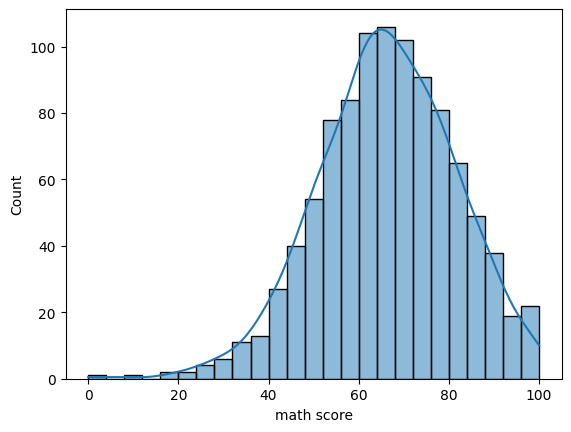

In [18]:
sns.histplot(data=df, x='math score', kde=True)
plt.show()

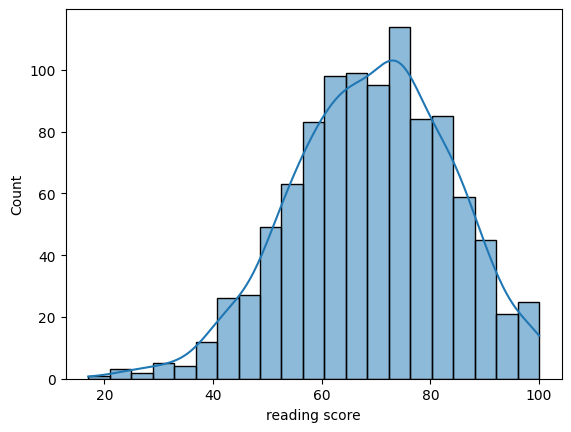

In [19]:
sns.histplot(data=df, x='reading score', kde=True)
plt.show()

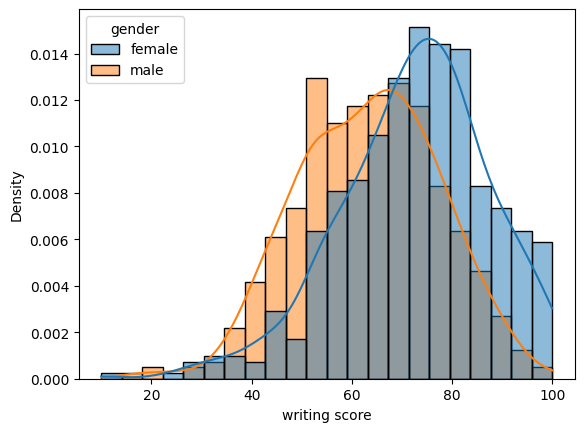

In [20]:
sns.histplot(data=df, x='writing score', kde=True, stat='density', hue='gender')
plt.show()

### KDE Plot

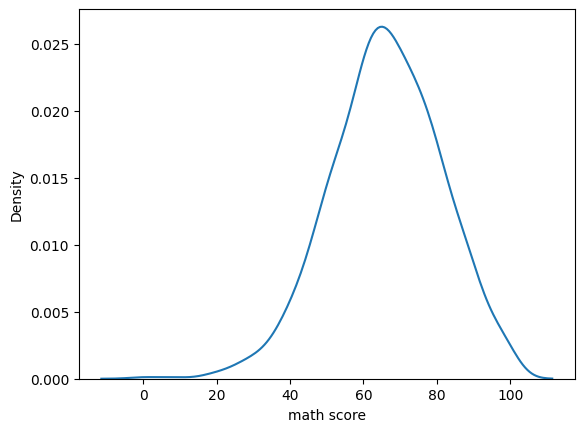

In [21]:
sns.kdeplot(data=df, x='math score')
plt.show()

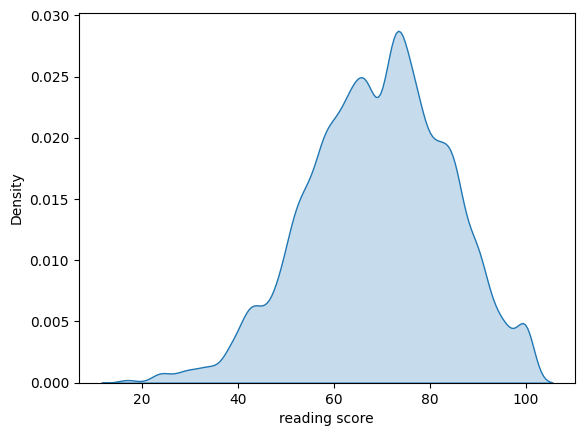

In [22]:
sns.kdeplot(data=df, x='reading score', fill=True, bw_adjust=0.5,)
plt.show()

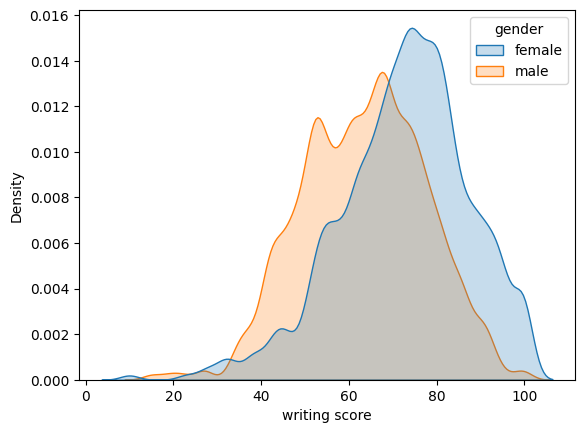

In [23]:
sns.kdeplot(data=df, x='writing score', fill=True, bw_adjust=0.5, hue='gender')
plt.show()

### Box Plot

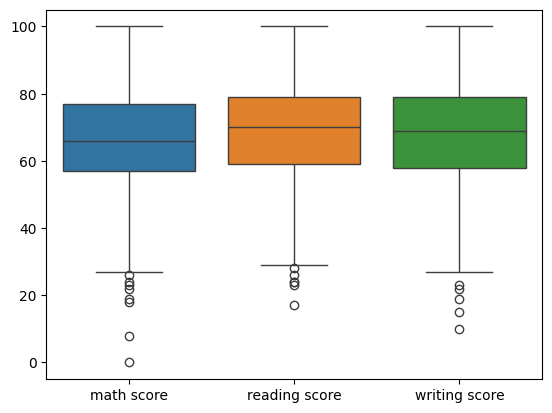

In [24]:
sns.boxplot(df[['math score','reading score', 'writing score']])
plt.show()

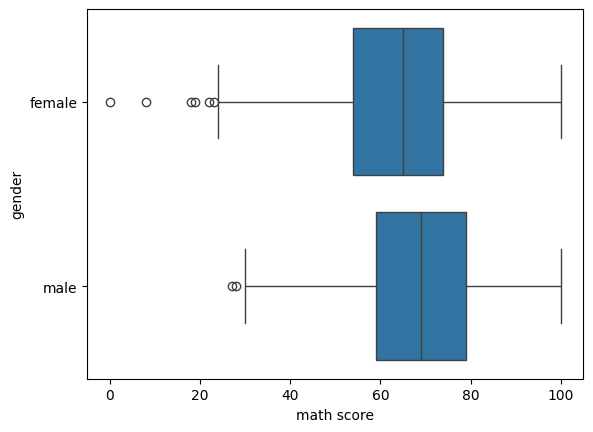

In [25]:
sns.boxplot(data=df, x='math score', y='gender')
plt.show()

In [26]:
df[['math score', 'reading score', 'writing score']].std()

math score       15.163080
reading score    14.600192
writing score    15.195657
dtype: float64

Questions
•	Are the distributions symmetric?
•	Is there any skewness?
•	Which subject has the highest variation?


## Questions - Distribution Analysis

**Are the distributions symmetric?**
No, the distributions are not perfectly symmetric.

**Is there any skewness?**
Yes, the distributions are slightly left-skewed, meaning more students scored higher and fewer scored low.

**Which subject has the highest variation?**
Writing score has the highest variation, indicating scores are more spread out compared to math and reading.

### Outlier Detection

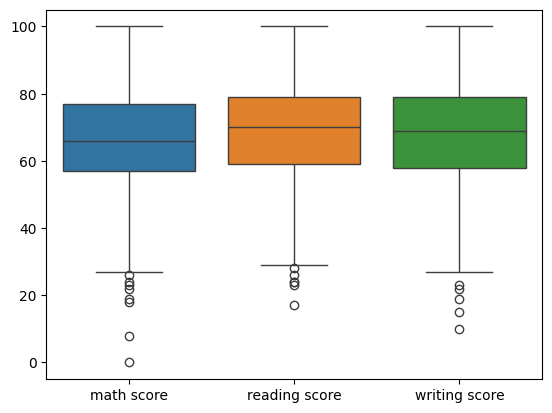

In [27]:
sns.boxplot(df[['math score','reading score', 'writing score']])
plt.show()

In [28]:
for col in ['math score','reading score', 'writing score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col} column has {len(outliers)} outliers.")

math score column has 8 outliers.
reading score column has 6 outliers.
writing score column has 5 outliers.


## Questions - Outlier Analysis

**Which subject contains the most outliers?**
Math score contains the most outliers compared to reading and writing scores.

**How might these affect analysis?**
Outliers can skew the mean, making it an unreliable measure of central tendency.
They can affect correlation and regression results if used in further analysis.
It is important to investigate whether these outliers are genuine low/high performers
or data entry errors before drawing conclusions.

### Category Frequency Analysis

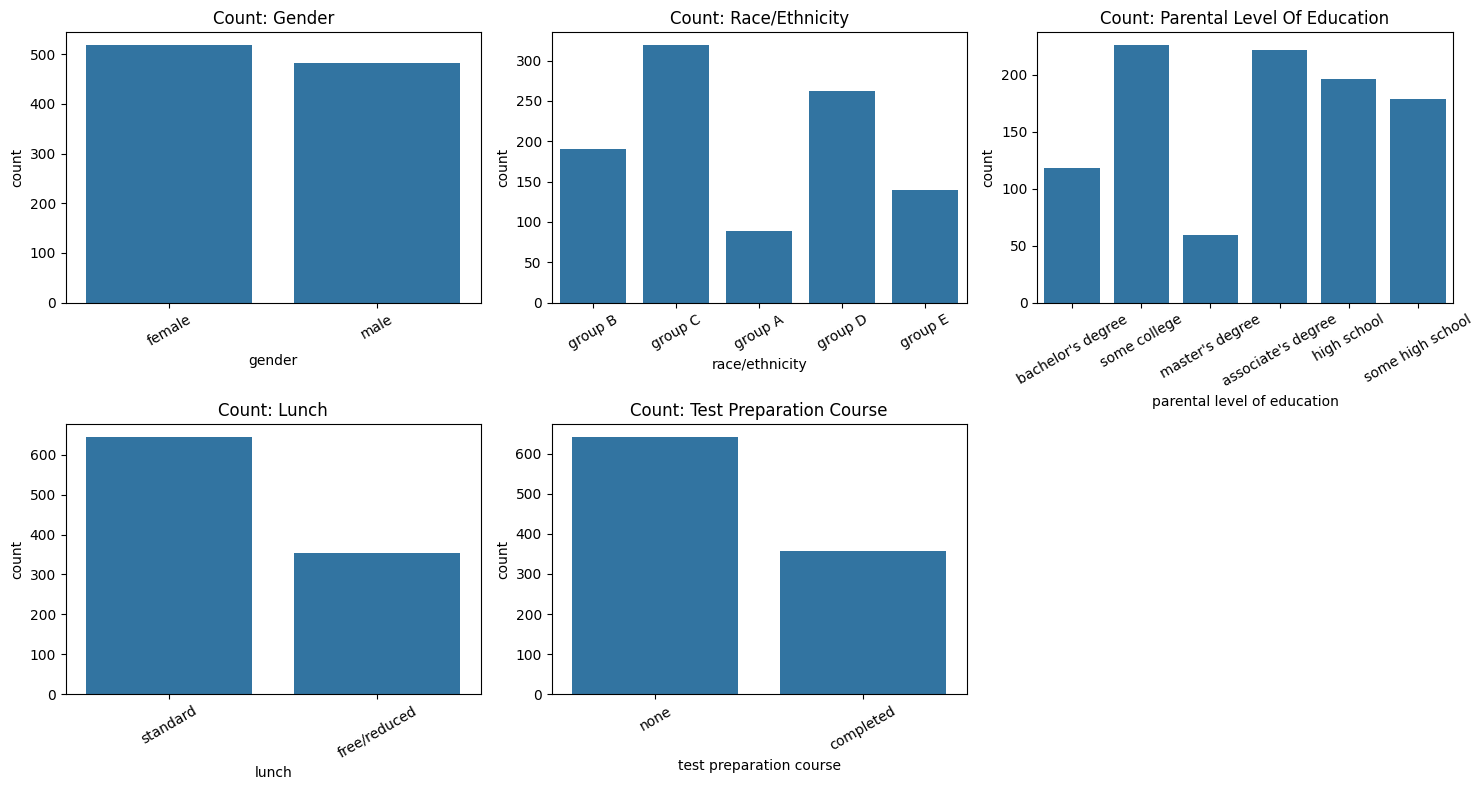

In [29]:
cols = ['gender','race/ethnicity','parental level of education','lunch','test preparation course']

fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.flatten()

for i,col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Count: {col.title()}')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [30]:
gfs = []

for col in cols:
    gfs.append(df[col].value_counts())
    print(f"Column:\t {df[col].value_counts()}")
    print("\n")

Column:	 gender
female    518
male      482
Name: count, dtype: int64


Column:	 race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64


Column:	 parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


Column:	 lunch
standard        645
free/reduced    355
Name: count, dtype: int64


Column:	 test preparation course
none         642
completed    358
Name: count, dtype: int64




In [31]:
gfs

[gender
 female    518
 male      482
 Name: count, dtype: int64,
 race/ethnicity
 group C    319
 group D    262
 group B    190
 group E    140
 group A     89
 Name: count, dtype: int64,
 parental level of education
 some college          226
 associate's degree    222
 high school           196
 some high school      179
 bachelor's degree     118
 master's degree        59
 Name: count, dtype: int64,
 lunch
 standard        645
 free/reduced    355
 Name: count, dtype: int64,
 test preparation course
 none         642
 completed    358
 Name: count, dtype: int64]

| | Category | Value | Count |
|---|---|---|---|
| **Most Frequent** | Lunch | Standard | 645 |
| **Least Frequent** | Parental Level of Education | Master's Degree | 59 |

In [32]:
for gf in gfs:
    print(f"Category: {gf.name}")
    print(f"Most frequent: {gf.idxmax()} ({gf.max()})")
    print(f"Leasr frequent: {gf.idxmin()} ({gf.min()})")
    print()

Category: count
Most frequent: female (518)
Leasr frequent: male (482)

Category: count
Most frequent: group C (319)
Leasr frequent: group A (89)

Category: count
Most frequent: some college (226)
Leasr frequent: master's degree (59)

Category: count
Most frequent: standard (645)
Leasr frequent: free/reduced (355)

Category: count
Most frequent: none (642)
Leasr frequent: completed (358)



# Section C: Bivariate Analysis

### Gender vs Academic Performance

In [33]:
df.groupby('gender')[['math score','reading score','writing score']].mean()

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


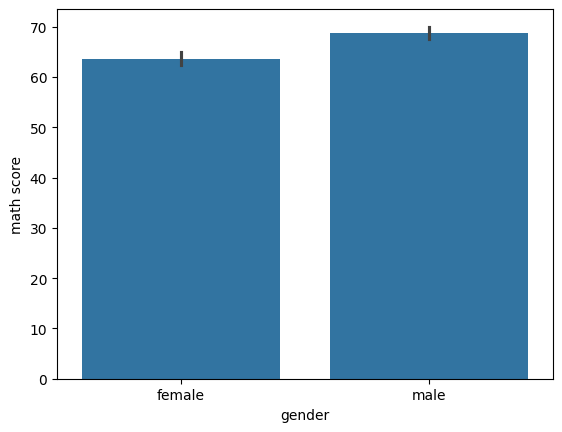

In [34]:
sns.barplot(data=df, x='gender', y='math score')
plt.show()

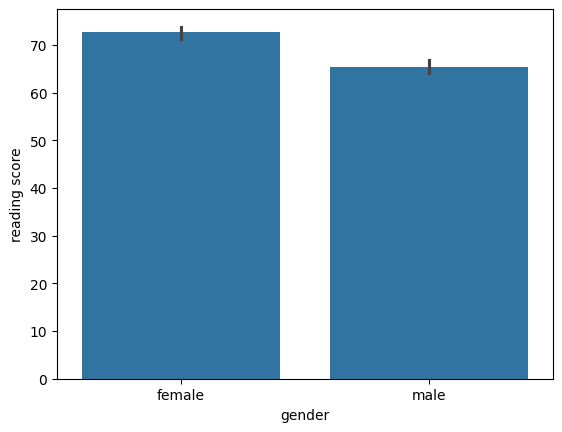

In [35]:
sns.barplot(data=df, x='gender', y='reading score')
plt.show()

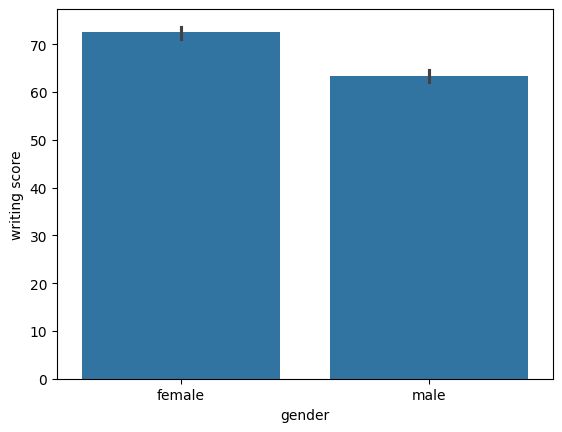

In [36]:
sns.barplot(data=df, x='gender', y='writing score')
plt.show()

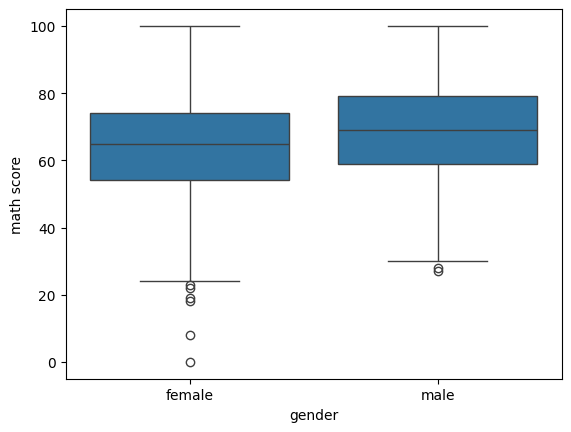

In [37]:
sns.boxplot(data=df, x='gender', y='math score')
plt.show()

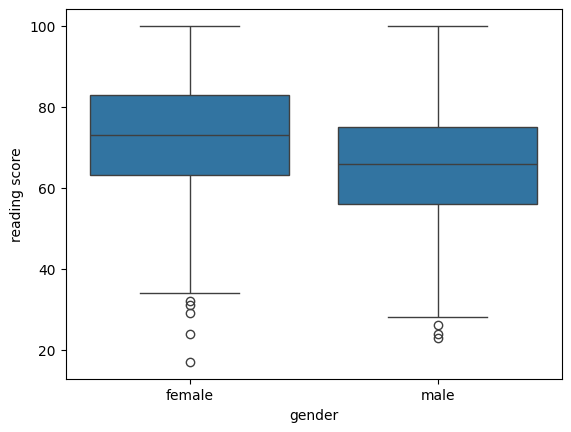

In [38]:
sns.boxplot(data=df, x='gender', y='reading score')
plt.show()

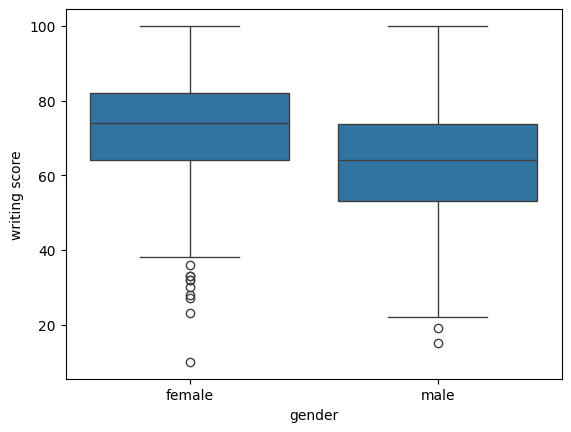

In [39]:
sns.boxplot(data=df, x='gender', y='writing score')
plt.show()

## Gender vs Academic Performance

**Which gender performs better in each subject?**
Males perform better in math, while females perform better in both reading and writing.

**Is the difference significant visually?**
Yes, the difference is visually noticeable. The gap is most prominent in reading and
writing scores where females clearly outperform males, while males show a moderate
advantage in math.

### Lunch Type vs Performance

In [40]:
df.groupby('lunch')[['math score','reading score','writing score']].mean()

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


In [41]:
df_melted = df.melt(
    id_vars='lunch',          # column to keep as-is
    value_vars=['math score', 'reading score', 'writing score'],  # columns to combine
    var_name='subject',       # name for the new "column names" column
    value_name='score'        # name for the new "values" column
)

In [42]:
df_melted.head()

,lunch,subject,score
0,standard,math score,72
1,standard,math score,69
2,standard,math score,90
3,free/reduced,math score,47
4,standard,math score,76


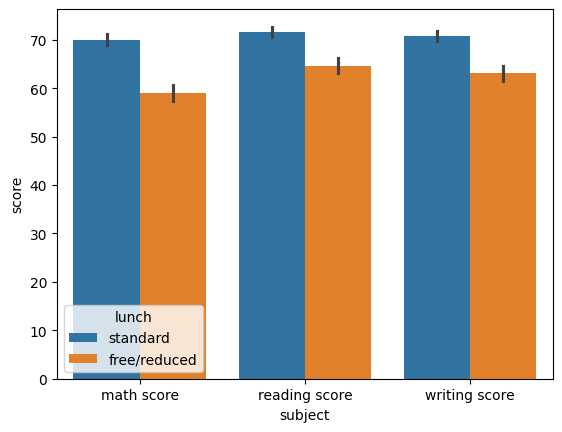

In [43]:
sns.barplot(data=df_melted, x='subject', y='score', hue='lunch')
plt.show()

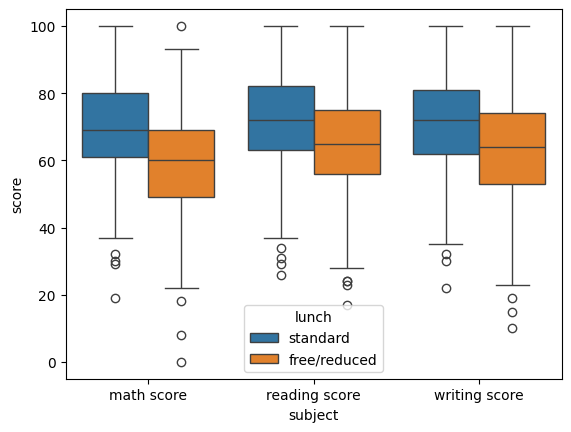

In [44]:
sns.boxplot(data=df_melted, x='subject', y='score', hue='lunch')
plt.show()

## Lunch Type vs Performance

**Which lunch group performs better?**
Students with standard lunch perform better across all three subjects compared
to students with free/reduced lunch.

**What conclusions can be drawn?**
Students with standard lunch consistently score higher in math, reading, and writing.
This may suggest that better nutrition positively impacts academic performance,
or that standard lunch students come from higher income households with more
academic resources and support.

### Test Preparation Course Impact

In [45]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [46]:
df.groupby('test preparation course')[['math score','reading score','writing score']].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


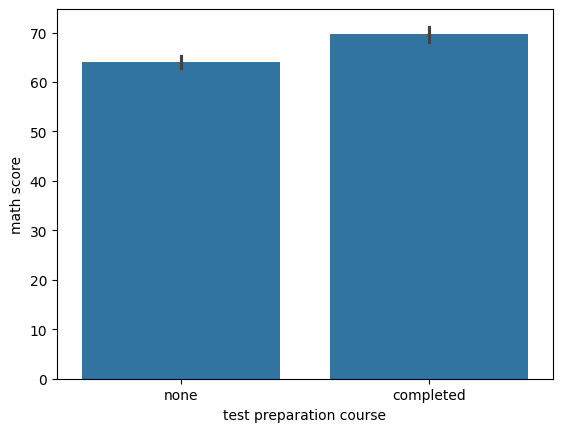

In [47]:
# bar plots
sns.barplot(data=df, x='test preparation course', y='math score')
plt.show()

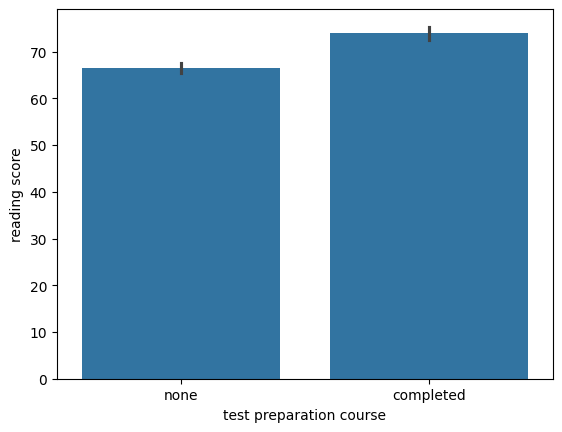

In [48]:

sns.barplot(data=df, x='test preparation course', y='reading score')
plt.show()



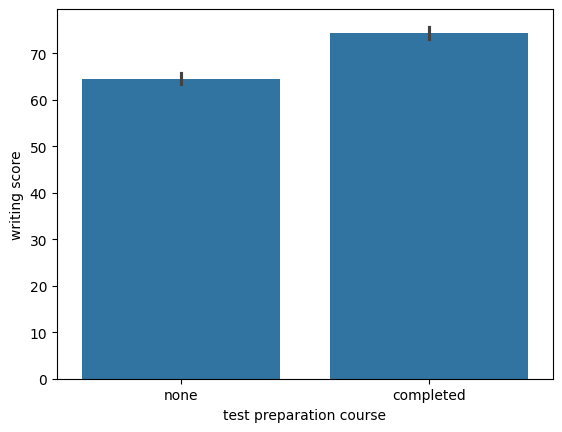

In [49]:
sns.barplot(data=df, x='test preparation course', y='writing score')
plt.show()


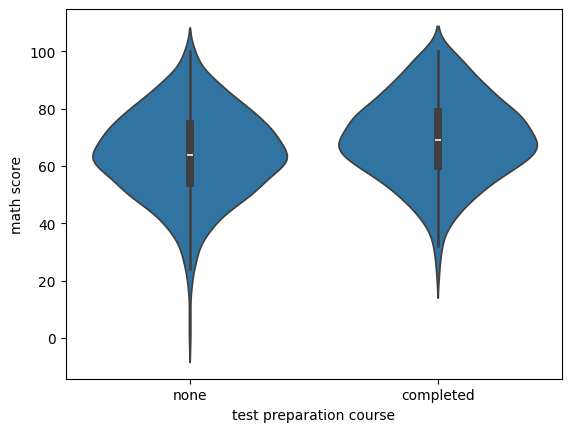

In [50]:

# violin plots
sns.violinplot(data=df, x='test preparation course', y='math score')
plt.show()


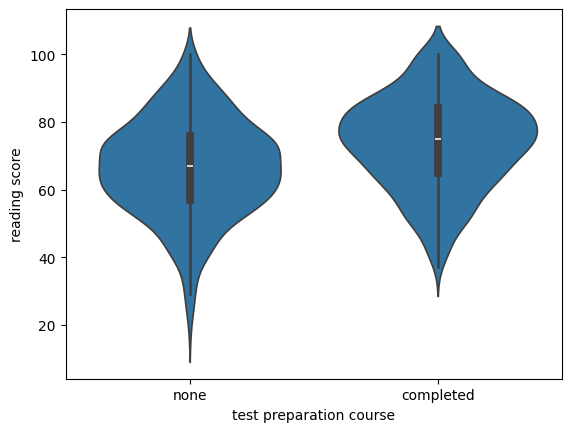

In [51]:

sns.violinplot(data=df, x='test preparation course', y='reading score')
plt.show()


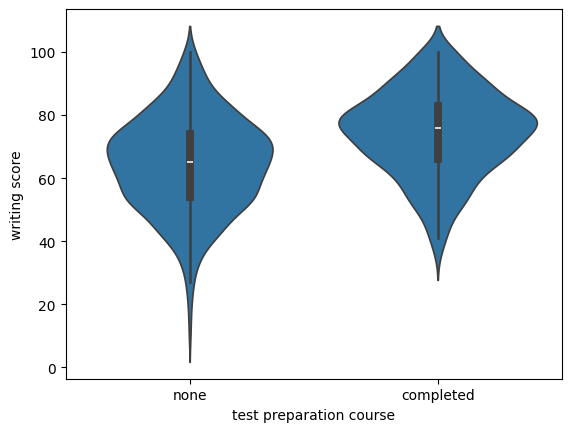

In [52]:

sns.violinplot(data=df, x='test preparation course', y='writing score')
plt.show()

## Test Preparation Course Impact

**Does test preparation improve performance?**
Yes, students who completed the test preparation course scored higher across
all subjects compared to those who did not.

**Which subject benefits most?**
Writing score benefits the most from test preparation, showing the largest
improvement between completed and none groups.

### Parental Education vs Student Scores

In [53]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [54]:
df.groupby('parental level of education')[['math score','reading score','writing score']].mean()

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


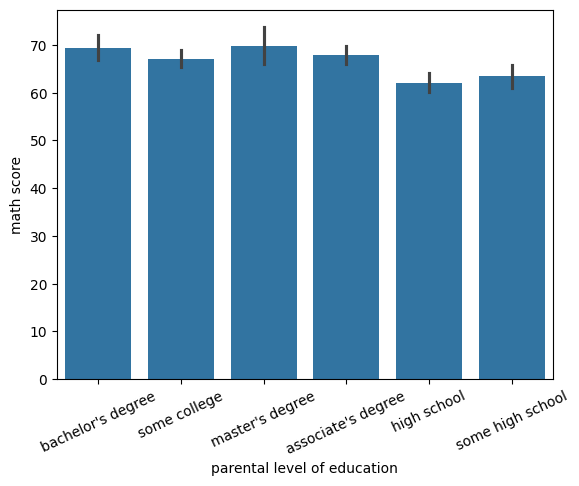

In [55]:
sns.barplot(data=df, x='parental level of education', y='math score')
plt.xticks(rotation=25)
plt.show()

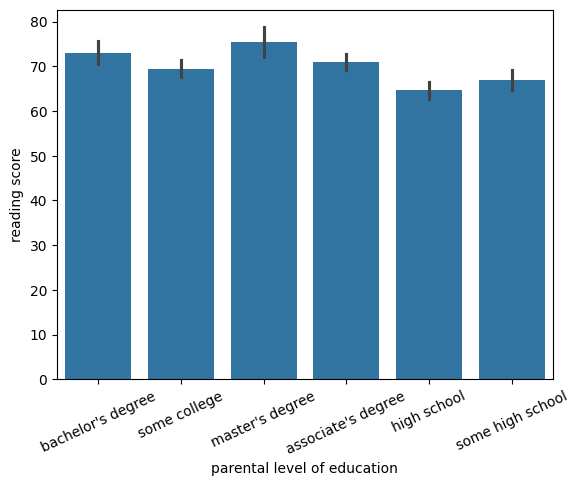

In [56]:
sns.barplot(data=df, x='parental level of education', y='reading score')
plt.xticks(rotation=25)
plt.show()

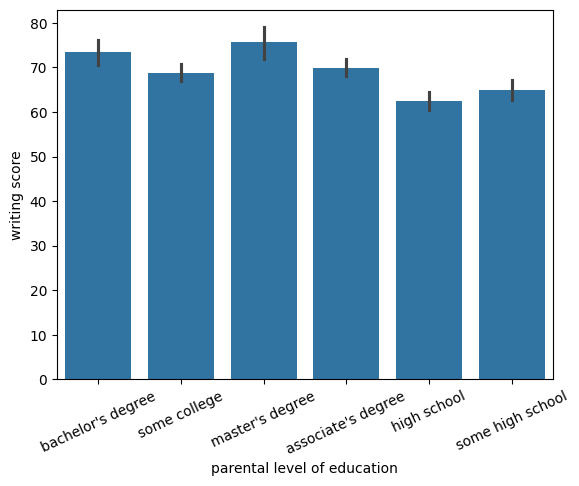

In [57]:
sns.barplot(data=df, x='parental level of education', y='writing score')
plt.xticks(rotation=25)
plt.show()

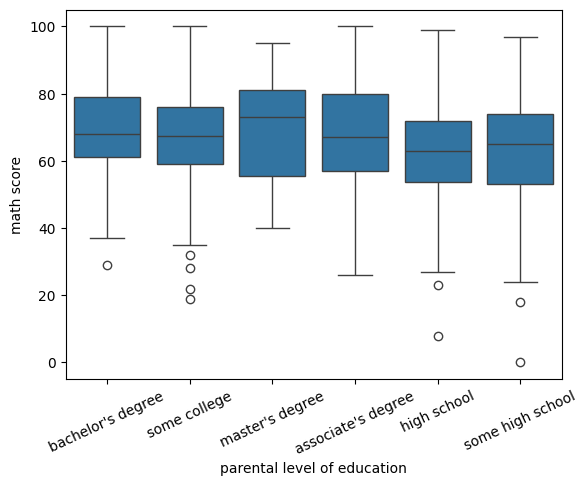

In [58]:
sns.boxplot(data=df, x='parental level of education', y='math score')
plt.xticks(rotation=25)
plt.show()

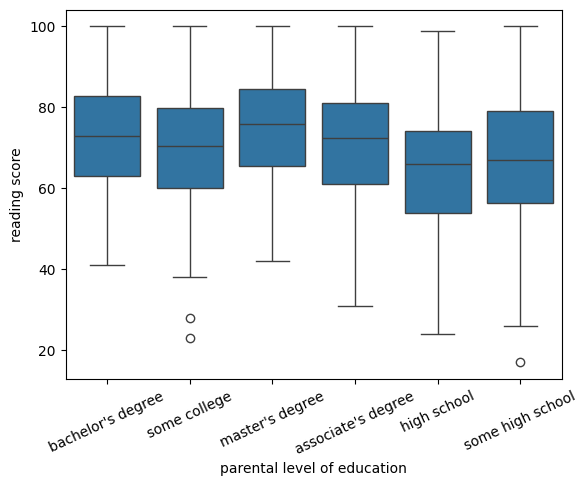

In [59]:
sns.boxplot(data=df, x='parental level of education', y='reading score')
plt.xticks(rotation=25)
plt.show()

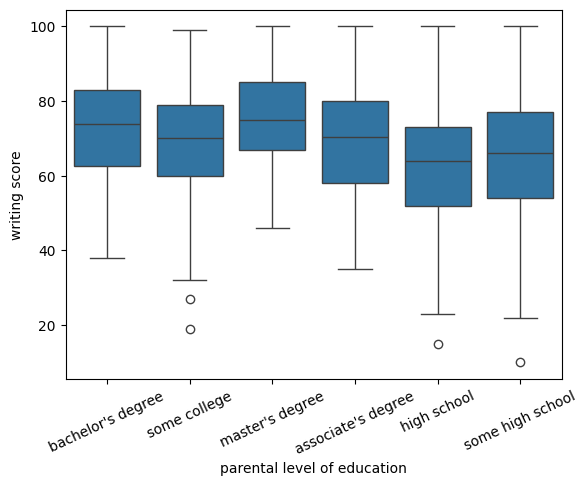

In [60]:
sns.boxplot(data=df, x='parental level of education', y='writing score')
plt.xticks(rotation=25)
plt.show()

## Questions & Answers

* **Does higher parental education correlate with better scores?**
Yes

* **Identify the best-performing education category.**
 reading score

# Section D: Multivariate Analysis
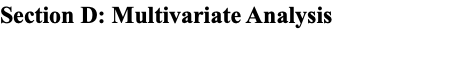
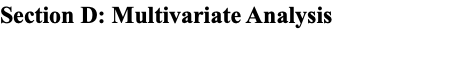
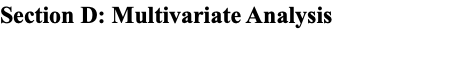
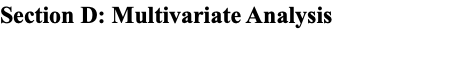

### Correlation Analysis

In [61]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [62]:
corr = df[['math score', 'reading score', 'writing score']].corr()

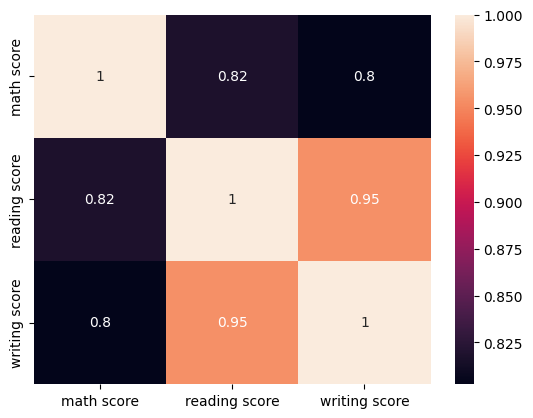

In [63]:
sns.heatmap(corr, annot=True)
plt.show()

## Correlation Analysis

**Interpretation:**
- Math vs Reading: 0.82 — strong positive correlation
- Math vs Writing: 0.80 — strong positive correlation
- Reading vs Writing: 0.95 — very strong positive correlation

## Questions

**Which pair has the strongest correlation?**
Reading and Writing (0.95) — students who score high in reading almost always score high in writing.

**Which pair has the weakest correlation?**
Math and Writing (0.80) — still strong, but the weakest among the three pairs.

### Pairwise Relationship Exploration
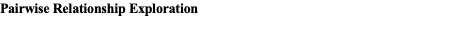
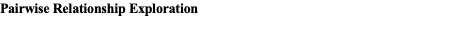
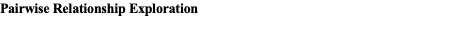
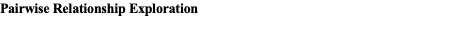

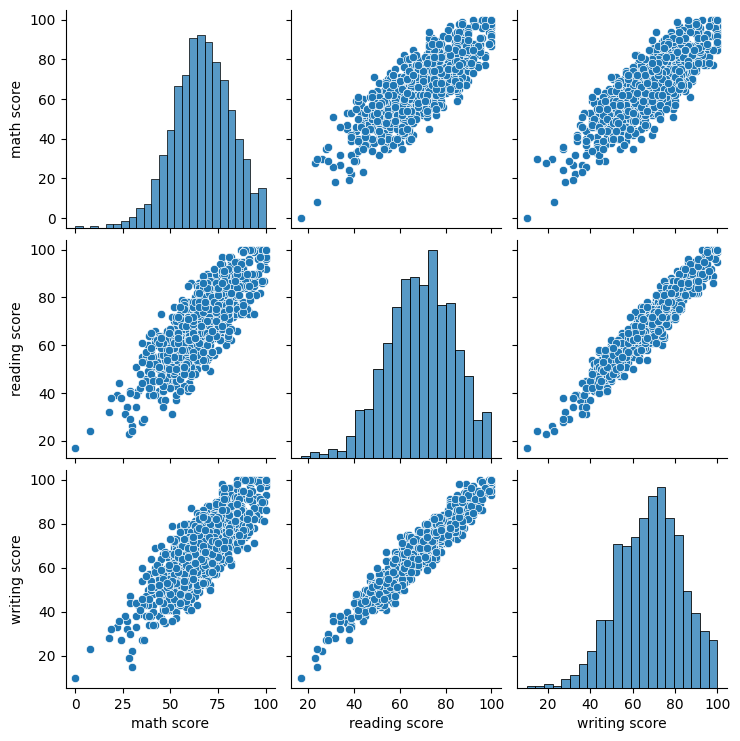

In [64]:
sns.pairplot(df[['math score', 'reading score', 'writing score']])
plt.show()

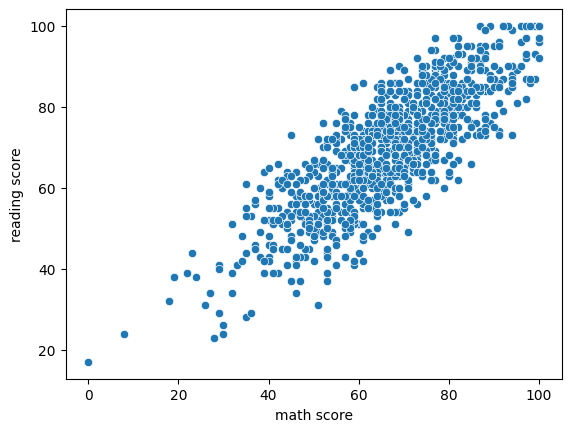

In [65]:
sns.scatterplot(data=df, x='math score',y='reading score')
plt.show()

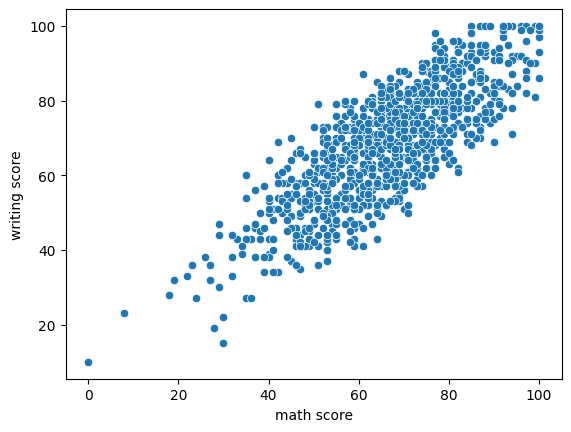

In [66]:
sns.scatterplot(data=df, x='math score',y='writing score')
plt.show()

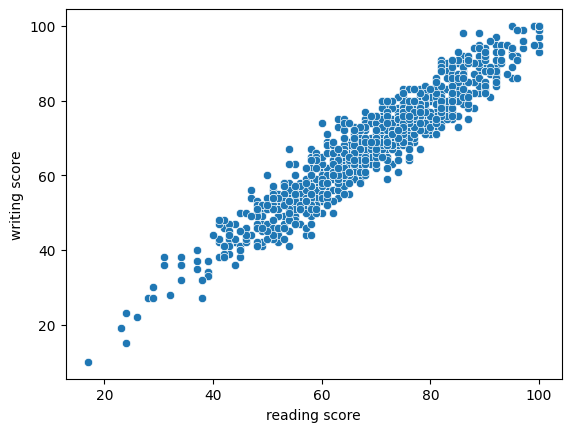

In [67]:
sns.scatterplot(data=df, x='reading score',y='writing score')
plt.show()

## Pairwise Relationship Exploration

**Are the relationships linear?**
Yes, all three pairs show a clear linear relationship — as one score increases,
the other increases proportionally.

**Which pair shows the strongest association?**
Reading and Writing show the strongest association, with points clustered
very tightly along a straight line, consistent with the correlation value of 0.95.

### Top and Bottom Performer Analysis

In [68]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [69]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']

In [70]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [71]:
top10 = df.nlargest(10, 'total score')
bottom10 = df.nsmallest(10, 'total score')

In [72]:
top10

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score
458,female,group E,bachelor's degree,standard,none,100,100,100,300
916,male,group E,bachelor's degree,standard,completed,100,100,100,300
962,female,group E,associate's degree,standard,none,100,100,100,300
114,female,group E,bachelor's degree,standard,completed,99,100,100,299
179,female,group D,some high school,standard,completed,97,100,100,297
712,female,group D,some college,standard,none,98,100,99,297
165,female,group C,bachelor's degree,standard,completed,96,100,100,296
625,male,group D,some college,standard,completed,100,97,99,296
149,male,group E,associate's degree,free/reduced,completed,100,100,93,293
685,female,group E,master's degree,standard,completed,94,99,100,293


In [73]:
bottom10

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score
59,female,group C,some high school,free/reduced,none,0,17,10,27
980,female,group B,high school,free/reduced,none,8,24,23,55
596,male,group B,high school,free/reduced,none,30,24,15,69
327,male,group A,some college,free/reduced,none,28,23,19,70
17,female,group B,some high school,free/reduced,none,18,32,28,78
76,male,group E,some high school,standard,none,30,26,22,78
601,female,group C,high school,standard,none,29,29,30,88
338,female,group B,some high school,free/reduced,none,24,38,27,89
787,female,group B,some college,standard,none,19,38,32,89
211,male,group C,some college,free/reduced,none,35,28,27,90


## Question - Top and Bottom Performer Analysis

**Common patterns among top performers:**
- Mostly from group D and group E
- Majority have standard lunch
- Parents have higher education (bachelor's or associate's degree)
- Mix of completed and none for test preparation

**Common patterns among low performers:**
- Mostly from group B and group C
- Majority have free/reduced lunch
- Parents have lower education (some high school or high school)
- Almost all have not completed test preparation course

# Section E: Feature Engineering
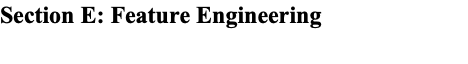
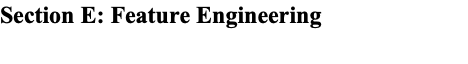
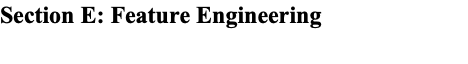
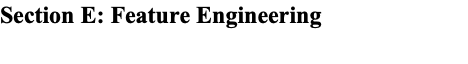